In [1]:
import pandas as pd
import sys
import os

# Setting up NARDINI script

In [2]:
exponential_fit = pd.read_csv('../../../output/GCN4_pipeline/speed/exponential_fit.csv', index_col=0)
exponential_fit = exponential_fit[['ADseq', 'A+C', 'k']].rename(
    columns={'A+C': 'strength', 'k': 'speed'}
)

exponential_fit

,ADseq,strength,speed
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898
...,...,...,...
1703,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,1.421365,0.151502
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,2.168666,0.059275
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.164379,0.185546
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.055855,0.160765


In [3]:
# ! mkdir ../../../output/GCN4_pipeline/speed/NARDINI

In [4]:
# os.chdir("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI")

In [5]:
# i = 0

# for seq in exponential_fit["ADseq"]:
#     if i%5 == 0:
#         print(i)
#     i += 1
    
#     SeqObj = SequenceParameters(seq)
#     SeqObj.save_zscoresAndPlots(num_scrambles=100000, random_seed=None)

# Interpreting NARDINI results

Ran this from the command line in the folder /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI:

find . -iname '*.zip' -exec sh -c 'unzip -o -d "${0%.*}" "$0"' '{}' ';'

In [6]:
import pandas as pd
import os
from pathlib import Path

In [9]:
from pathlib import Path

rootdir = Path('/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI_retry')

file_list = list(rootdir.glob('seq_*/nardini-data-*/sequences.tsv'))

print(len(file_list))
print(file_list[:3])

1557
[PosixPath('/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI_retry/seq_0392/nardini-data-PWA4LSFN7T/sequences.tsv'), PosixPath('/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI_retry/seq_0568/nardini-data-NH62KXROW1/sequences.tsv'), PosixPath('/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI_retry/seq_0904/nardini-data-P1K6F846HH/sequences.tsv')]


In [10]:
# rootdir = Path('/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/NARDINI_retry//')

# # Find all sequences.tsv files anywhere under rootdir
# file_list = list(rootdir.glob('**/sequences.tsv'))
# print(len(file_list))

In [12]:
import tqdm

In [13]:
rows = []
for tsv_path in tqdm.tqdm(file_list):
    filepath = tsv_path.parent  # the folder containing the TSVs
    
    seq_df = pd.read_csv(filepath / "sequences.tsv", delim_whitespace=True)
    seq = seq_df["original_seq"].iloc[0]
    
    z_score_matrix = pd.read_csv(filepath / "zscore-original-sequence-seq1.tsv", delim_whitespace=True)
    z_score_matrix.index = z_score_matrix.columns
    
    long_df = z_score_matrix.reset_index().melt(id_vars='index', var_name='Column', value_name='Value')
    long_df.rename(columns={'index': 'Row'}, inplace=True)
    long_df["seq"] = seq
    
    long_df['Pair'] = long_df.apply(lambda x: tuple(sorted([x['Row'], x['Column']])), axis=1)
    long_df = long_df.sort_values(by="Value", ascending=False)
    long_df = long_df.drop_duplicates(subset=['Pair'])
    
    pairwise_row_df = long_df.pivot(index="seq", columns='Pair', values='Value')
    pairwise_row_df.reset_index(drop=True, inplace=True)
    pairwise_row_df["seq"] = seq
    
    rows.append(pairwise_row_df)

100%|██████████| 1557/1557 [00:56<00:00, 27.38it/s]


In [14]:
results = pd.concat(rows).set_index("seq").reset_index()
results

Pair,seq,"(+, +)","(+, -)","(+, A)","(+, G)","(+, P)","(+, h)","(+, µ)","(+, π)","(-, -)",...,"(P, P)","(P, h)","(P, µ)","(P, π)","(h, h)","(h, µ)","(h, π)","(µ, µ)","(µ, π)","(π, π)"
0,FPASPDVSPDVSFYSPADLNLHLGTTDFESINHPAPASDS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.950438,...,0.128953,0.649166,0.000000,0.0,-0.346641,0.000000,0.0,-1.748770,0.0,0.00000
1,INFNSVVEQMPAQTVSPKDLMMDSSAPPSTSFTDMSTPSF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,-0.240723,0.953608,0.000000,0.0,0.061348,0.185345,0.0,-0.104185,0.0,0.00000
2,NWTSLFDDDVEIKVEDVFGADAAGASITQFEQQKPEPVIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.573736,...,0.000000,0.000000,0.000000,0.0,-0.069810,1.253260,0.0,3.082630,0.0,0.00000
3,SEQYSAPNSSAFTNLTTPSNFGESPEYENYEVSPNFGDFD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.439930,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,-0.252069,0.0,-1.63330
4,NGDMDHSLAGDPWYPLFPPEDQFEVPKIEDSSPLLPEEEL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.077818,...,-0.207079,0.000000,1.069680,0.0,-1.192840,0.000000,0.0,1.219110,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,APNSAALTSLTSPSDFNDSPYGDSYDVSPNFGGNDFEAGA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.163391,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,-0.684399,0.0,-1.81159
1553,PSQLYNNPPNSTPPTTTPSDFPFPETLTSSTASRSRFSLP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,1.177140,0.000000,0.412398,0.0,0.000000,0.000000,0.0,0.091711,0.0,0.00000
1554,VPLFACNSTGNLQDQRTTNMSRPTFPEDMLFDLGDFPASP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.977044,...,0.677714,0.273027,3.020480,0.0,0.262260,1.895300,0.0,2.407270,0.0,0.00000
1555,ASQWEPEMENSLNLWDLAHHTHLPLLHNITMDHGKERNDC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.048254,...,0.000000,0.000000,0.000000,0.0,0.273973,0.000000,0.0,-0.027651,0.0,0.00000


In [15]:
# missed_seqs = exponential_fit[~exponential_fit["ADseq"].isin(results["seq"])]
# missed_seqs.to_csv("../../../output/GCN4_pipeline/speed/exponential_fit_nardini_missed.csv")
# missed_seqs

In [16]:
# Now, adding identifiers

In [17]:
exponential_fit = exponential_fit.rename(columns = {"ADseq" : "seq"})
exponential_fit

,seq,strength,speed
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898
...,...,...,...
1703,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,1.421365,0.151502
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,2.168666,0.059275
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.164379,0.185546
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.055855,0.160765


In [18]:
exponential_fit_results = pd.merge(exponential_fit, results, how = "left", on = "seq")
exponential_fit_results

,seq,strength,speed,"(+, +)","(+, -)","(+, A)","(+, G)","(+, P)","(+, h)","(+, µ)",...,"(P, P)","(P, h)","(P, µ)","(P, π)","(h, h)","(h, µ)","(h, π)","(µ, µ)","(µ, π)","(π, π)"
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,-0.345043,0.000000,0.000000,-0.360993,0.000000,0.000000
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.412787,0.000000,0.042848
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,2.216290,1.641870,0.042848
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.778964,1.862450,0.561751,1.445940,1.434030,0.048466
4,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.259455,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,1.421365,0.151502,0.047795,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,-0.887363,0.670590,0.061078,2.055310,1.676680,1.144860
1553,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,2.168666,0.059275,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.58879,0.000000,0.0,0.0,-0.823404,0.269604,0.000000,-0.344704,0.000000,0.000000
1554,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.164379,0.185546,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.200341,0.072805,-0.014337
1555,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.055855,0.160765,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.03735,0.180156,0.0,0.0,-0.741582,0.000000,0.000000,1.256660,0.000000,0.000000


In [19]:
exponential_fit_results[pd.isnull(exponential_fit_results).any(axis=1)]

,seq,strength,speed,"(+, +)","(+, -)","(+, A)","(+, G)","(+, P)","(+, h)","(+, µ)",...,"(P, P)","(P, h)","(P, µ)","(P, π)","(h, h)","(h, µ)","(h, π)","(µ, µ)","(µ, π)","(π, π)"


In [20]:
exponential_fit_results.to_csv("../../../output/GCN4_pipeline/speed/NARDINI/GCN4_NARDINI_results.csv")

In [21]:
exponential_fit_results_no_na = exponential_fit_results.dropna()
exponential_fit_results_no_na

,seq,strength,speed,"(+, +)","(+, -)","(+, A)","(+, G)","(+, P)","(+, h)","(+, µ)",...,"(P, P)","(P, h)","(P, µ)","(P, π)","(h, h)","(h, µ)","(h, π)","(µ, µ)","(µ, π)","(π, π)"
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,-0.345043,0.000000,0.000000,-0.360993,0.000000,0.000000
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.412787,0.000000,0.042848
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,2.216290,1.641870,0.042848
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.778964,1.862450,0.561751,1.445940,1.434030,0.048466
4,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.259455,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,1.421365,0.151502,0.047795,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,-0.887363,0.670590,0.061078,2.055310,1.676680,1.144860
1553,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,2.168666,0.059275,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.58879,0.000000,0.0,0.0,-0.823404,0.269604,0.000000,-0.344704,0.000000,0.000000
1554,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.164379,0.185546,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.200341,0.072805,-0.014337
1555,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.055855,0.160765,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.03735,0.180156,0.0,0.0,-0.741582,0.000000,0.000000,1.256660,0.000000,0.000000


,feature_set,n_samples,n_features
0,nardini,1557,36


,feature_set,target,model,split,r2,rmse,pearson_r
0,nardini,speed,Linear regression,5-fold CV,0.078907,0.046773,0.303681
1,nardini,speed,Ridge regression,5-fold CV,0.109776,0.045983,0.331754
2,nardini,strength,Linear regression,5-fold CV,0.164526,1.082095,0.412967
3,nardini,strength,Ridge regression,5-fold CV,0.179659,1.072250,0.424144
4,nardini,speed,Linear regression,holdout,0.107310,0.045895,0.337229
5,nardini,speed,Ridge regression,holdout,0.117910,0.045621,0.345574
6,nardini,strength,Linear regression,holdout,0.187114,1.090372,0.442357
7,nardini,strength,Ridge regression,holdout,0.207589,1.076552,0.456269


,feature_set,target,selected_alpha
0,nardini,speed,10.000000
1,nardini,strength,5.011872


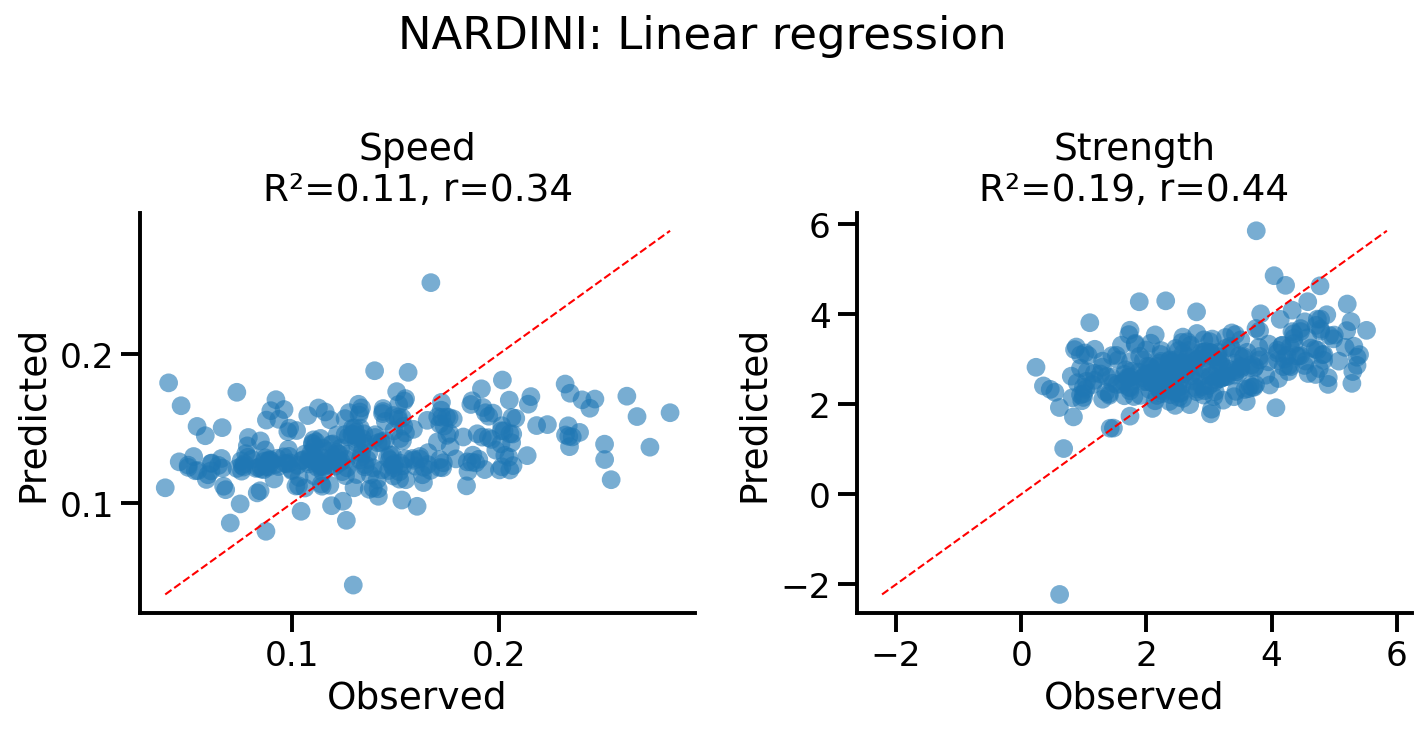

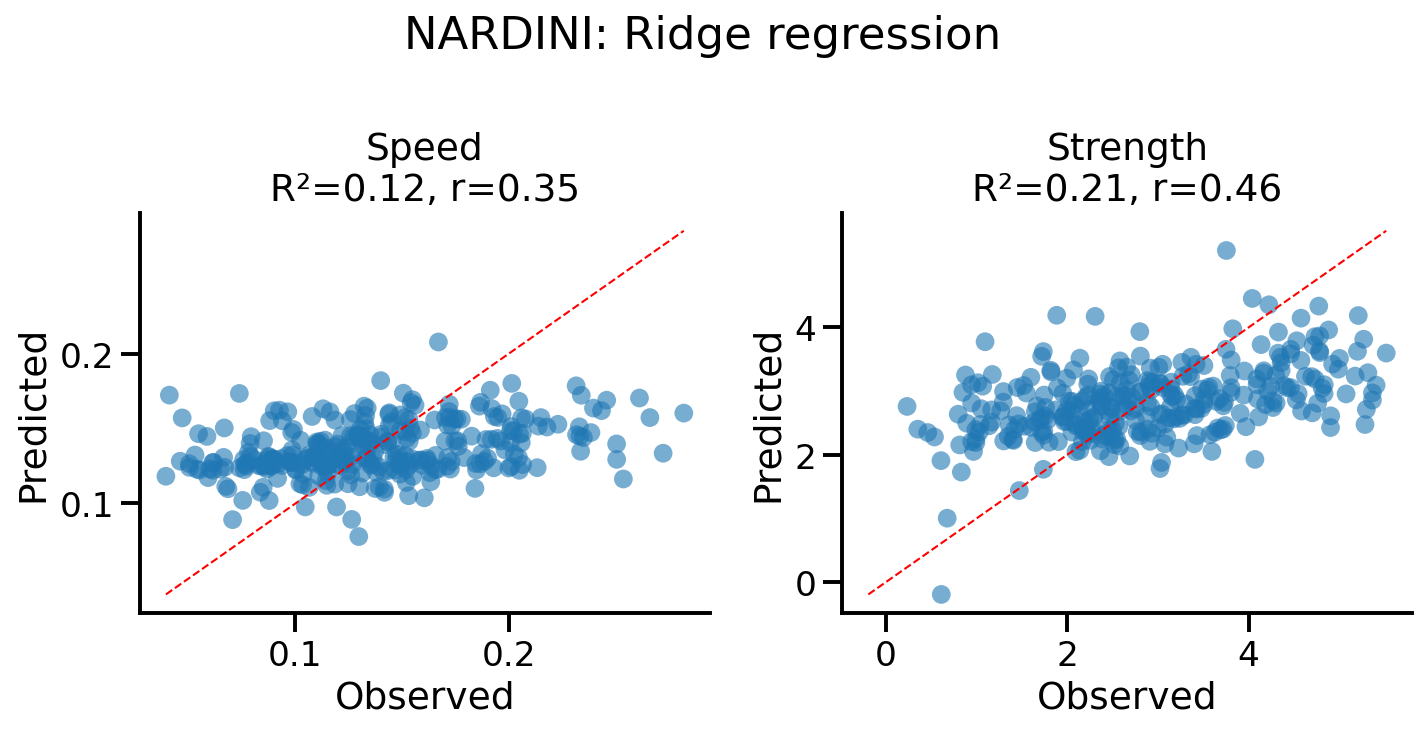


Top 12 NARDINI features — SPEED (Linear)


,feature,coef,abs_coef
0,"(+, +)",-0.051780,0.051780
14,"(-, π)",0.049996,0.049996
16,"(A, G)",-0.029521,0.029521
8,"(-, -)",-0.020431,0.020431
2,"(+, A)",0.019874,0.019874
21,"(G, G)",0.018623,0.018623
32,"(h, π)",0.017720,0.017720
25,"(G, π)",-0.016674,0.016674
7,"(+, π)",0.016559,0.016559
9,"(-, A)",0.014703,0.014703



Top 12 NARDINI features — STRENGTH (Linear)


,feature,coef,abs_coef
14,"(-, π)",1.495747,1.495747
6,"(+, µ)",-1.091236,1.091236
5,"(+, h)",-0.805226,0.805226
4,"(+, P)",-0.720652,0.720652
32,"(h, π)",0.710127,0.710127
7,"(+, π)",-0.628474,0.628474
2,"(+, A)",0.553115,0.553115
25,"(G, π)",0.499500,0.499500
8,"(-, -)",-0.468124,0.468124
22,"(G, P)",0.454275,0.454275


In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

RANDOM_STATE = 42

# ── helpers ──────────────────────────────────────────────────────────────────
def safe_pearson(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return pearsonr(y_true, y_pred)[0]

def metric_row(y_true, y_pred, feature_set, target_name, model_name, split_name):
    return {
        'feature_set': feature_set,
        'target':      target_name,
        'model':       model_name,
        'split':       split_name,
        'r2':          r2_score(y_true, y_pred),
        'rmse':        mean_squared_error(y_true, y_pred) ** 0.5,
        'pearson_r':   safe_pearson(y_true, y_pred),
    }

def evaluate_model(builder, X, y, feature_set, target_name, train_idx, test_idx, cv):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    estimator = builder()
    estimator.fit(X_train, y_train)
    y_test_pred = estimator.predict(X_test)

    cv_estimator = builder()
    y_cv_pred = cross_val_predict(cv_estimator, X, y, cv=cv)

    summary_rows = [
        metric_row(y_test, y_test_pred, feature_set, target_name, estimator.__class__.__name__, 'holdout'),
        metric_row(y,      y_cv_pred,   feature_set, target_name, estimator.__class__.__name__, '5-fold CV'),
    ]
    return summary_rows, {
        'estimator':   estimator,
        'y_test':      y_test,
        'y_test_pred': y_test_pred,
        'y_cv_pred':   y_cv_pred,
    }

def benchmark_models(X, targets, model_builders, feature_set, train_idx, test_idx, cv):
    rows, artifacts = [], {}
    for target_name, y in targets.items():
        for model_name, builder in model_builders.items():
            summary_rows, artifact = evaluate_model(
                builder, X, y, feature_set, target_name, train_idx, test_idx, cv
            )
            for row in summary_rows:
                row['model'] = model_name
            rows.extend(summary_rows)
            artifacts[(feature_set, target_name, model_name)] = artifact
    return pd.DataFrame(rows), artifacts

def coefficient_table(model, feature_names, n=12):
    coef = np.asarray(model.coef_).reshape(-1)
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    return coef_df.sort_values('abs_coef', ascending=False).head(n)

def plot_prediction_grid(artifacts, feature_set, model_name, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
    for ax, target_name in zip(axes, ['speed', 'strength']):
        artifact = artifacts[(feature_set, target_name, model_name)]
        y_true = artifact['y_test']
        y_pred = artifact['y_test_pred']
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='none')
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_title(
            f"{target_name.capitalize()}\n"
            f"R²={r2_score(y_true, y_pred):.2f}, r={safe_pearson(y_true, y_pred):.2f}"
        )
        ax.set_xlabel('Observed')
        ax.set_ylabel('Predicted')
    fig.suptitle(f'{title_prefix}: {model_name}', y=0.99)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ── NARDINI feature matrix ────────────────────────────────────────────────────
drop_cols   = ['seq', 'strength', 'speed']
feature_cols = [c for c in exponential_fit_results_no_na.columns if c not in drop_cols]

nardini_df = exponential_fit_results_no_na[feature_cols].reset_index(drop=True)

targets = {
    'speed':    exponential_fit_results_no_na['speed'].to_numpy(),
    'strength': exponential_fit_results_no_na['strength'].to_numpy(),
}

# ── train/test split & CV ────────────────────────────────────────────────────
train_idx, test_idx = train_test_split(
    np.arange(len(nardini_df)), test_size=0.2, random_state=RANDOM_STATE
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── feature set summary ───────────────────────────────────────────────────────
display(pd.DataFrame({
    'feature_set': ['nardini'],
    'n_samples':   [len(nardini_df)],
    'n_features':  [nardini_df.shape[1]],
}))

# ── fit models ────────────────────────────────────────────────────────────────
linear_models = {'Linear regression': lambda: LinearRegression()}
ridge_alphas  = np.logspace(-4, 4, 81)
ridge_models  = {'Ridge regression':  lambda: RidgeCV(alphas=ridge_alphas)}

nardini_linear_summary, nardini_linear_artifacts = benchmark_models(
    nardini_df, targets, linear_models, 'nardini', train_idx, test_idx, cv
)
nardini_ridge_summary, nardini_ridge_artifacts = benchmark_models(
    nardini_df, targets, ridge_models, 'nardini', train_idx, test_idx, cv
)

# ── combined summary table ────────────────────────────────────────────────────
model_summary = (
    pd.concat([nardini_linear_summary, nardini_ridge_summary], ignore_index=True)
    .sort_values(['split', 'target', 'model', 'r2'], ascending=[True, True, True, False])
    .reset_index(drop=True)
)
display(model_summary)

# ── ridge selected alphas ─────────────────────────────────────────────────────
ridge_alpha_rows = []
for target_name in ['speed', 'strength']:
    ridge_alpha_rows.append({
        'feature_set':    'nardini',
        'target':         target_name,
        'selected_alpha': nardini_ridge_artifacts[('nardini', target_name, 'Ridge regression')]['estimator'].alpha_,
    })
display(pd.DataFrame(ridge_alpha_rows))

# ── plots ─────────────────────────────────────────────────────────────────────
plot_prediction_grid(nardini_linear_artifacts, 'nardini', 'Linear regression', 'NARDINI')
plot_prediction_grid(nardini_ridge_artifacts,  'nardini', 'Ridge regression',  'NARDINI')

# ── top coefficients (linear model) ──────────────────────────────────────────
for target_name in ['speed', 'strength']:
    model = nardini_linear_artifacts[('nardini', target_name, 'Linear regression')]['estimator']
    print(f"\nTop 12 NARDINI features — {target_name.upper()} (Linear)")
    display(coefficient_table(model, feature_cols))

,feature_set,n_samples,n_features
0,nardini,1557,36
1,composition,1557,20
2,nardini+composition,1557,56


,feature_set,target,model,split,r2,rmse,pearson_r
0,composition,speed,Ridge regression,5-fold CV,0.307955,0.040543,0.555046
1,composition,speed,Linear regression,5-fold CV,0.307844,0.040546,0.555193
2,nardini,speed,Ridge regression,5-fold CV,0.109776,0.045983,0.331754
3,nardini,speed,Linear regression,5-fold CV,0.078907,0.046773,0.303681
4,nardini+composition,speed,Linear regression,5-fold CV,0.296230,0.040885,0.549502
5,nardini+composition,speed,Ridge regression,5-fold CV,0.295064,0.040919,0.545796
6,composition,strength,Ridge regression,5-fold CV,0.582638,0.764813,0.763322
7,composition,strength,Linear regression,5-fold CV,0.582526,0.764916,0.763326
8,nardini,strength,Ridge regression,5-fold CV,0.179659,1.072250,0.424144
9,nardini,strength,Linear regression,5-fold CV,0.164526,1.082095,0.412967


,feature_set,target,selected_alpha
0,nardini,speed,10.000000
1,nardini,strength,5.011872
2,composition,speed,0.012589
3,composition,strength,0.006310
4,nardini+composition,speed,0.039811
5,nardini+composition,strength,0.010000


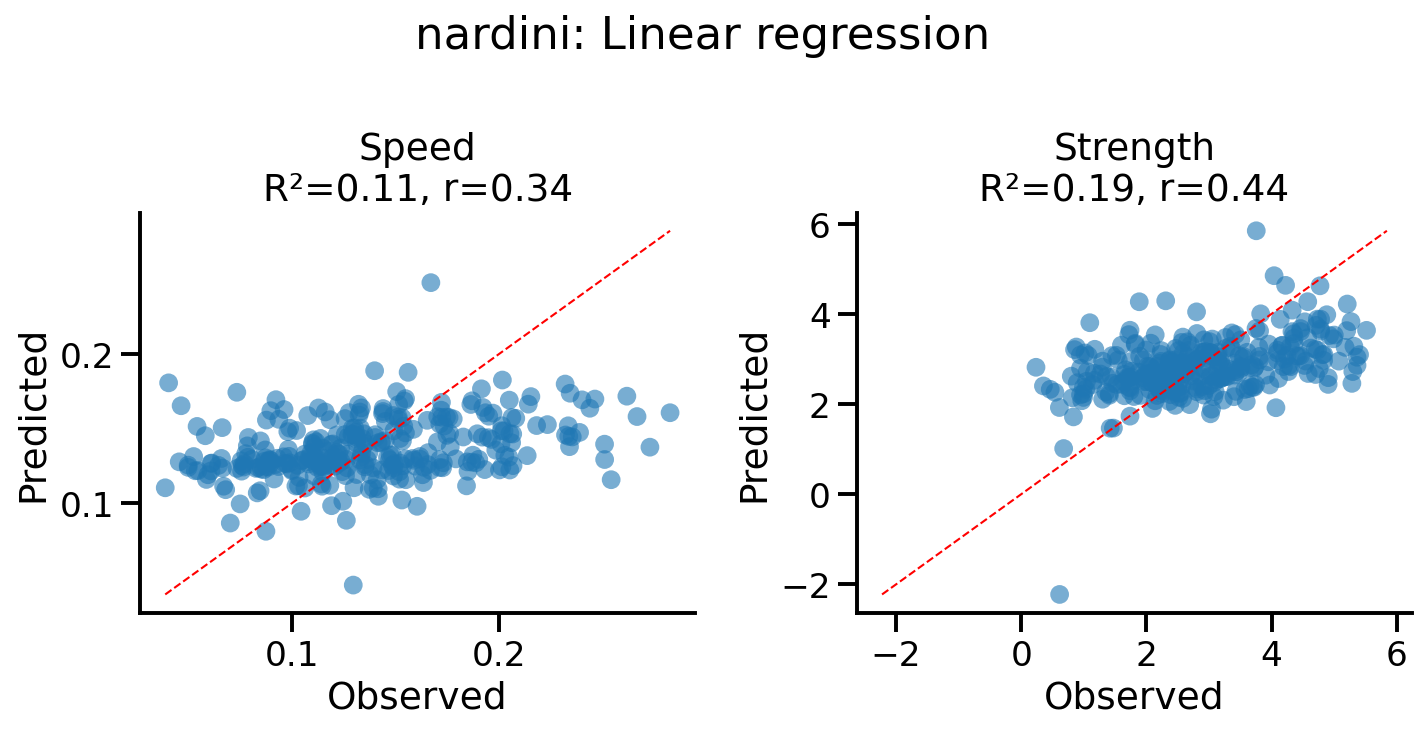

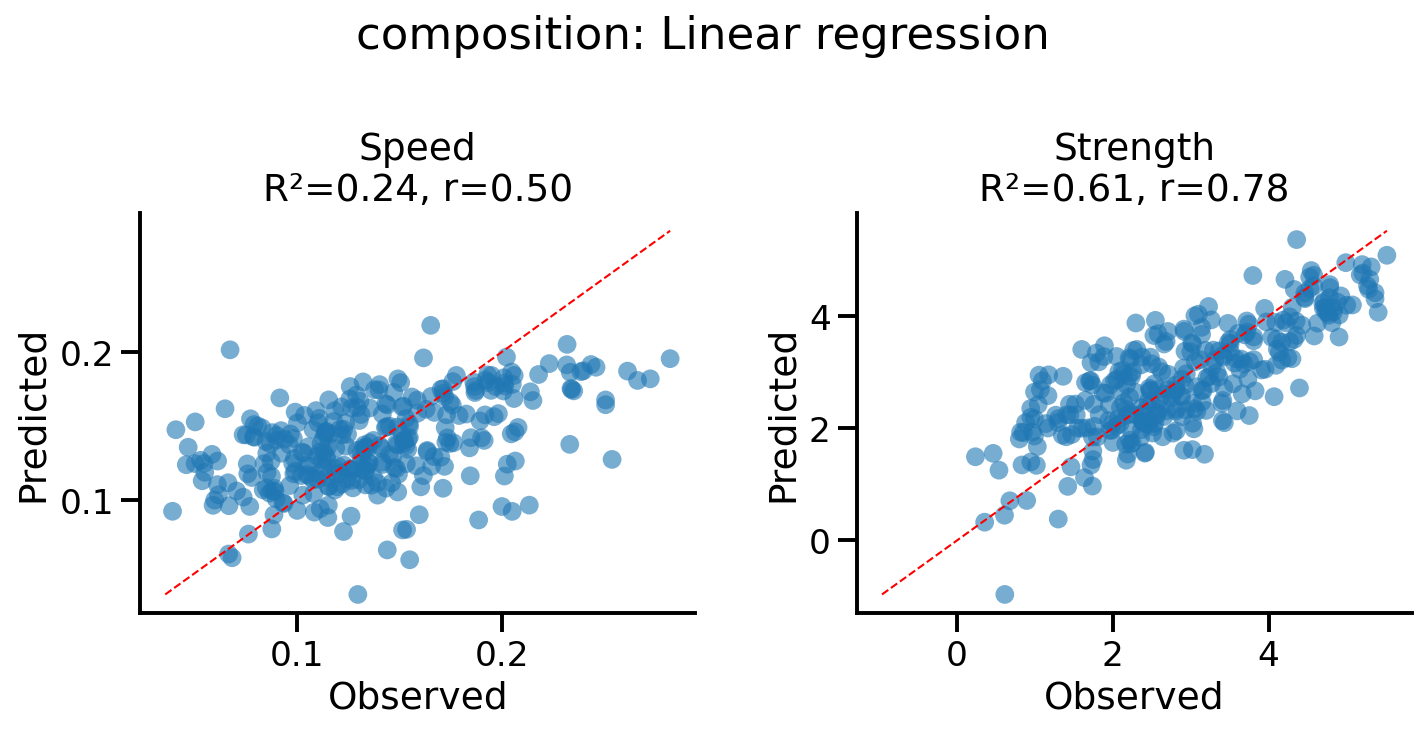

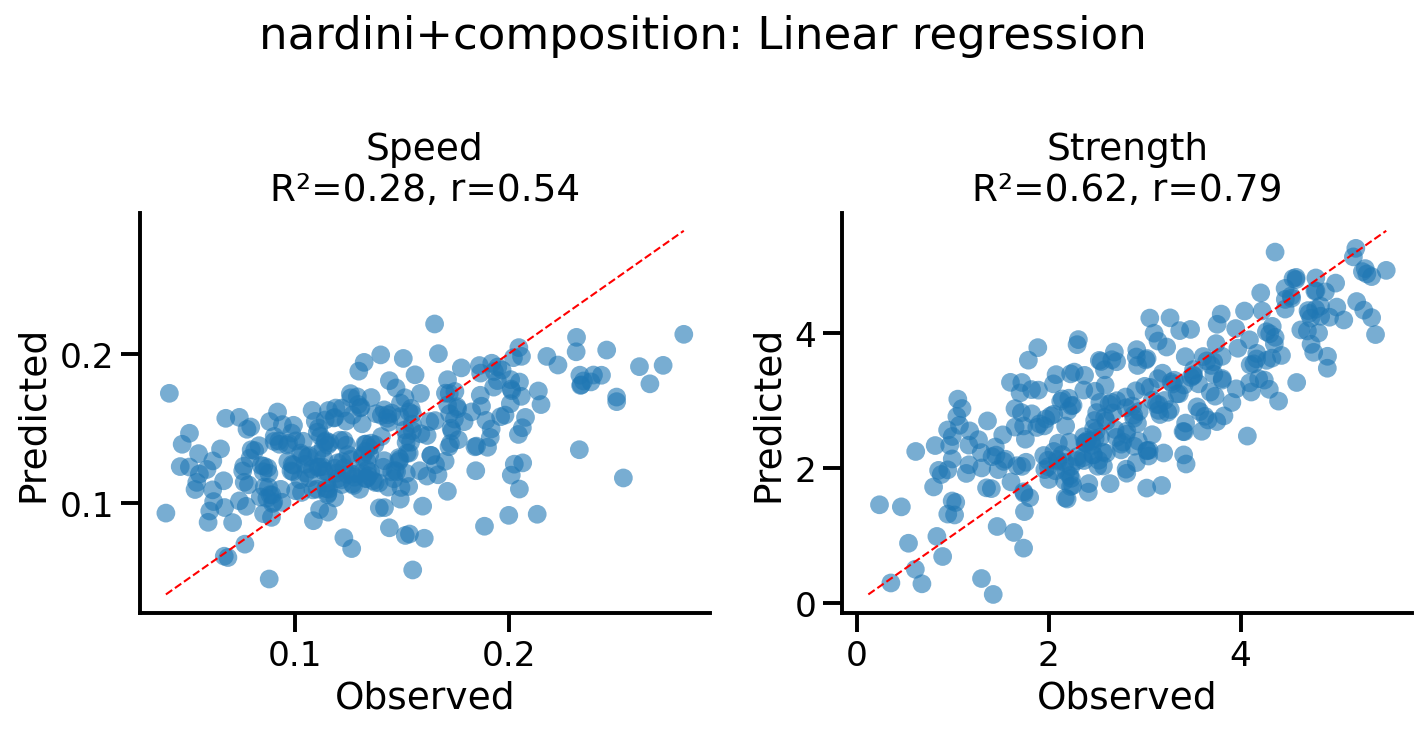


Top 12 features — SPEED (Linear, nardini+composition)


,feature,coef,abs_coef
54,W,0.704745,0.704745
37,C,-0.529400,0.529400
40,F,0.484721,0.484721
50,R,-0.366038,0.366038
38,D,0.256822,0.256822
46,M,0.246965,0.246965
44,K,-0.234497,0.234497
53,V,-0.105205,0.105205
47,N,-0.093545,0.093545
42,H,-0.092608,0.092608



Top 12 features — STRENGTH (Linear, nardini+composition)


,feature,coef,abs_coef
54,W,24.540300,24.540300
40,F,14.832106,14.832106
50,R,-13.627101,13.627101
44,K,-13.514797,13.514797
46,M,9.590036,9.590036
42,H,-7.178280,7.178280
49,Q,-7.063717,7.063717
45,L,6.779196,6.779196
55,Y,5.933533,5.933533
47,N,-5.318292,5.318292


In [23]:
from collections import Counter

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

def aa_composition(seq):
    counts = Counter(seq)
    length = len(seq)
    return {aa: counts.get(aa, 0) / length for aa in AMINO_ACIDS}

# NARDINI features
drop_cols    = ['seq', 'strength', 'speed']
feature_cols = [c for c in exponential_fit_results_no_na.columns if c not in drop_cols]
nardini_df   = exponential_fit_results_no_na[feature_cols].reset_index(drop=True)
nardini_df.columns = [str(c) for c in nardini_df.columns]

# composition features
composition_df = pd.DataFrame(
    exponential_fit_results_no_na['seq'].apply(aa_composition).tolist()
).reset_index(drop=True)

# combined
combined_df = pd.concat([nardini_df, composition_df], axis=1)

targets = {
    'speed':    exponential_fit_results_no_na['speed'].to_numpy(),
    'strength': exponential_fit_results_no_na['strength'].to_numpy(),
}

# ── train/test split & CV ─────────────────────────────────────────────────────
train_idx, test_idx = train_test_split(
    np.arange(len(combined_df)), test_size=0.2, random_state=RANDOM_STATE
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

display(pd.DataFrame({
    'feature_set': ['nardini', 'composition', 'nardini+composition'],
    'n_samples':   [len(nardini_df)] * 3,
    'n_features':  [nardini_df.shape[1], composition_df.shape[1], combined_df.shape[1]],
}))

# ── fit ───────────────────────────────────────────────────────────────────────
linear_models = {'Linear regression': lambda: LinearRegression()}
ridge_alphas  = np.logspace(-4, 4, 81)
ridge_models  = {'Ridge regression':  lambda: RidgeCV(alphas=ridge_alphas)}

summaries, all_artifacts = [], {}

for feat_name, feat_df in [
    ('nardini',             nardini_df),
    ('composition',         composition_df),
    ('nardini+composition', combined_df),
]:
    for model_dict, mname in [(linear_models, 'linear'), (ridge_models, 'ridge')]:
        s, a = benchmark_models(feat_df, targets, model_dict, feat_name, train_idx, test_idx, cv)
        summaries.append(s)
        all_artifacts.update(a)

# ── summary table ─────────────────────────────────────────────────────────────
model_summary = (
    pd.concat(summaries, ignore_index=True)
    .sort_values(['split', 'target', 'feature_set', 'r2'], ascending=[True, True, True, False])
    .reset_index(drop=True)
)
display(model_summary)

# ── ridge selected alphas ─────────────────────────────────────────────────────
ridge_alpha_rows = []
for feat_name in ['nardini', 'composition', 'nardini+composition']:
    for target_name in ['speed', 'strength']:
        key = (feat_name, target_name, 'Ridge regression')
        if key in all_artifacts:
            ridge_alpha_rows.append({
                'feature_set':    feat_name,
                'target':         target_name,
                'selected_alpha': all_artifacts[key]['estimator'].alpha_,
            })
display(pd.DataFrame(ridge_alpha_rows))

# ── plots ─────────────────────────────────────────────────────────────────────
for feat_name in ['nardini', 'composition', 'nardini+composition']:
    plot_prediction_grid(all_artifacts, feat_name, 'Linear regression', feat_name)

# ── top coefficients (ridge, combined) ───────────────────────────────────────
combined_feature_names = list(combined_df.columns)
for target_name in ['speed', 'strength']:
    model = all_artifacts[('nardini+composition', target_name, 'Linear regression')]['estimator']
    print(f"\nTop 12 features — {target_name.upper()} (Linear, nardini+composition)")
    display(coefficient_table(model, combined_feature_names))